# Importing Libraries & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/heart_attack_prediction_indonesia.csv')


In [10]:
df.select_dtypes(include='number').columns

Index(['age', 'hypertension', 'diabetes', 'cholesterol_level', 'obesity',
       'waist_circumference', 'family_history', 'sleep_hours',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl',
       'triglycerides', 'previous_heart_disease', 'medication_usage',
       'participated_in_free_screening', 'heart_attack'],
      dtype='object')

#EDA


##Notes:
* there is no duplicates.
* there is no nulls except ``alcohol_consumption``. the percentage of it is: **~60%**
---
####**Numarical Columns:**

* ``cholesterol_level`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* The minimum of ``waist_circumference`` isn't normal (isn't even insight). The Min should be 45. The Max is ok (Look at ***Numbers & Researchs*** Section).
* ``sleep_hours`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* ``blood_pressure_systolic`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* ``blood_pressure_diastolic`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* ``fasting_blood_sugar`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* ``cholesterol_hdl`` is in the normal range (Look at ***Numbers & Researchs*** Section).
* The minimum of ``cholesterol_ldl`` isn't normal (isn't even insight). The Min should be 10. The Max is ok (Look at ***Numbers & Researchs*** Section).
* ``triglycerides`` is in the normal range (Look at ***Numbers & Researchs*** Section).
---
####**Catigorical Columns:**
``hypertension``, ``diabetes``, ``obesity``,``family_history``, ``previous_heart_disease``, ``medication_usage``, ``participated_in_free_screening``, ``heart_attack`` : Aren't Numrical but **Binary** Columns.

In [3]:
df.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,Male,Rural,Middle,0,1,211,0,83,0,...,62,173,48,121,101,Normal,0,0,0,0
1,53,Female,Urban,Low,0,0,208,0,106,1,...,76,70,58,83,138,Normal,1,0,1,0
2,62,Female,Urban,Low,0,0,231,1,112,1,...,74,118,69,130,171,Abnormal,0,1,0,1
3,73,Male,Urban,Low,1,0,202,0,82,1,...,65,98,52,85,146,Normal,0,1,1,0
4,52,Male,Urban,Middle,1,0,232,0,89,0,...,75,104,59,127,139,Normal,1,0,1,1


In [4]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          # 'Outliars':outliars,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df



In [5]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[54, 56, 55, 52, 53, 57, 58, 51, 50, 59]",66,0,0.000000,0
1,gender,object,"[Male, Female]",2,0,0.000000,0
2,region,object,"[Urban, Rural]",2,0,0.000000,0
3,income_level,object,"[Middle, Low, High]",3,0,0.000000,0
4,hypertension,int64,"[0, 1]",2,0,0.000000,0
5,diabetes,int64,"[0, 1]",2,0,0.000000,0
6,cholesterol_level,int64,"[203, 199, 198, 196, 201, 197, 207, 195, 200, ...",247,0,0.000000,0
7,obesity,int64,"[0, 1]",2,0,0.000000,0
8,waist_circumference,int64,"[91, 93, 94, 96, 95, 92, 98, 89, 90, 97]",136,0,0.000000,0
9,family_history,int64,"[0, 1]",2,0,0.000000,0


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,158355.0,54.543778,11.910897,25.0,46.000000,55.000000,63.00000,90.0
hypertension,158355.0,0.299069,0.457851,0.0,0.000000,0.000000,1.00000,1.0
diabetes,158355.0,0.199804,0.399854,0.0,0.000000,0.000000,0.00000,1.0
cholesterol_level,158355.0,199.533264,39.737565,100.0,172.000000,199.000000,226.00000,350.0
obesity,158355.0,0.249901,0.432957,0.0,0.000000,0.000000,0.00000,1.0
waist_circumference,158355.0,93.268504,16.382205,20.0,82.000000,93.000000,104.00000,173.0
family_history,158355.0,0.300218,0.458354,0.0,0.000000,0.000000,1.00000,1.0
sleep_hours,158355.0,6.480064,1.425398,3.0,5.492985,6.507461,7.52064,9.0
blood_pressure_systolic,158355.0,129.515772,15.005641,61.0,119.000000,130.000000,140.00000,199.0
blood_pressure_diastolic,158355.0,79.490809,10.002964,37.0,73.000000,80.000000,86.00000,127.0


#Preaprosscing:

##Notes:

###Numbers & Researchs:
---
####-**Numbers**
| Variable | Minimum value (alive patient) | Maximum value (critical but possible alive patient) | Unit | Note |
|---|---:|---:|---|---|
| cholesterol_level (Total Cholesterol) | 80 | 500 | mg/dL | Very low or very high values can occur clinically |
| waist_circumference | 45 | 220 | cm | Very high values represent severe obesity/metabolic risk |
| sleep_hours | 1 | 18 | hours/day | Extreme short or long sleep durations can be recorded |
| blood_pressure_systolic | 60 | 260 | mmHg | Severe hypotension or hypertension may occur in living patients |
| blood_pressure_diastolic | 30 | 160 | mmHg | Extreme values are clinically possible |
| fasting_blood_sugar | 30 | 700 | mg/dL | Severe hyperglycemia has been reported in living patients |
| cholesterol_hdl | 5 | 120 | mg/dL | Extremely low/high HDL values are possible |
| cholesterol_ldl | 10 | 400 | mg/dL | Very high LDL can occur clinically |
| triglycerides | 20 | 2000 | mg/dL | Severe hypertriglyceridemia can occur in living patients |

######-**Note:**
* The clinical interpretation follows Asian-specific metabolic risk thresholds where available.
* Asian populations may develop metabolic complications at lower waist circumference and BMI values compared with Western populations.
* Extreme values represent medically severe but potentially survivable conditions and should not be interpreted as death-related values.
---

#### Researchs (Verified References)

| Variables supported | Reference | Type | Supports | Link |
|---|---|---|---|---|
| Waist circumference, Asian population risk | WHO Expert Consultation. "Appropriate body-mass index for Asian populations and its implications for policy and intervention strategies." The Lancet (2004) | Expert Consultation / Review | Supports Asian-specific obesity and metabolic risk interpretation | https://doi.org/10.1016/S0140-6736(03)15268-3 |
| Waist circumference, glucose, HDL, triglycerides, blood pressure | Alberti KGMM et al. "Harmonizing the Metabolic Syndrome." Circulation (2009) | Scientific Statement | Supports metabolic syndrome components and ethnic waist considerations | https://doi.org/10.1161/CIRCULATIONAHA.109.192644 |
| Blood pressure categories | Indonesian Society of Hypertension (InaSH). "Konsensus Penanganan Hipertensi." (2019) | Clinical Guideline | Supports BP classification used in Indonesian clinical practice | https://inash.or.id |
| Fasting blood glucose classification | American Diabetes Association. Standards of Care in Diabetes | Clinical Guideline | Supports normal glucose, prediabetes, diabetes thresholds | https://diabetesjournals.org/care/issue |
| Total cholesterol, LDL, HDL, triglycerides | National Cholesterol Education Program (NCEP ATP III) | Clinical Guideline | Supports lipid profile categories | https://www.nhlbi.nih.gov/files/docs/guidelines/atp3xsum.pdf |
| Severe triglycerides | Berglund L et al. "Evaluation and Treatment of Hypertriglyceridemia." Circulation (2012) | Scientific Statement | Supports severe and very severe triglyceride categories | https://doi.org/10.1161/CIR.0b013e3182160726 |
| Sleep duration and health risks | Itani O et al. "Short sleep duration and health outcomes: systematic review, meta-analysis, and meta-regression." Sleep Medicine (2017) | Systematic Review + Meta-analysis | Supports sleep duration association with metabolic/health risks | https://doi.org/10.1016/j.sleep.2017.05.015 |
| Indonesian adult health measurements | Indonesia Basic Health Research (Riskesdas) | Population Survey | Supports Indonesian population health data | https://www.badankebijakan.kemkes.go.id |

---


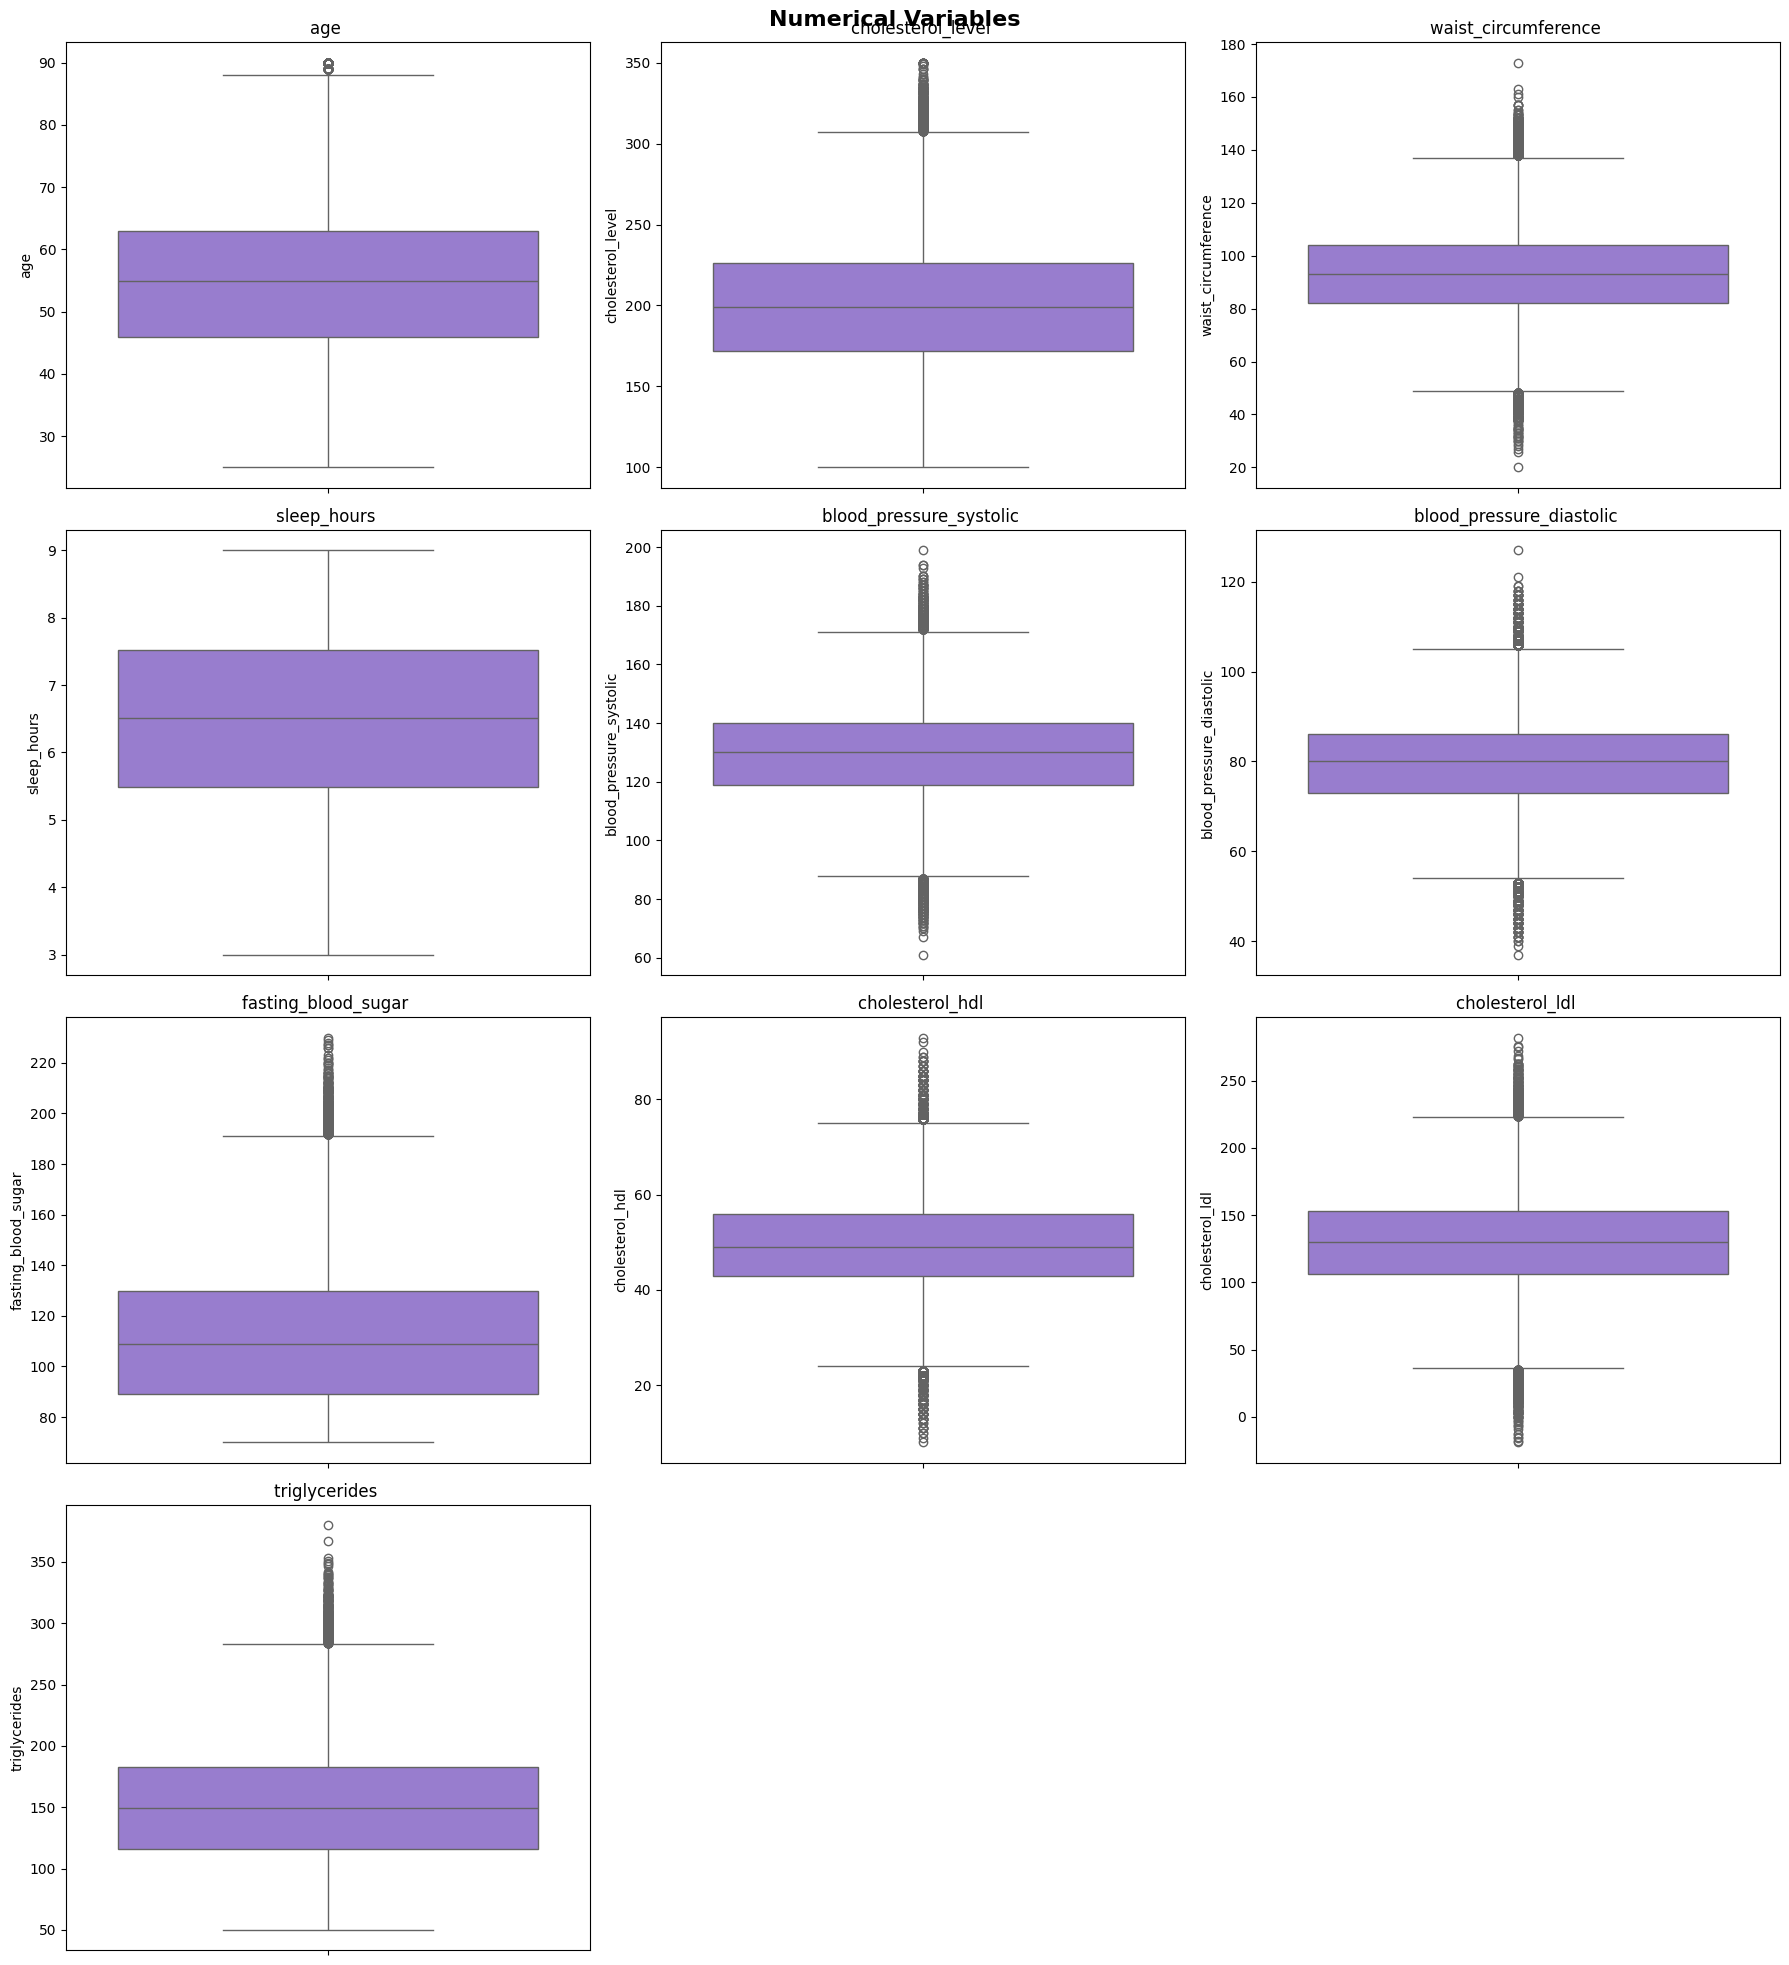

In [18]:
# nums=df.select_dtypes(include=['int64','float64']).columns
nums=['age','cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(nums):
    sns.boxplot(data=df, y=col, ax=axes[i],color='#9370DB')
    axes[i].set_title(f'{col} ', fontsize=12)
    axes[i].set_ylabel(col)

for j in range(len(nums), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

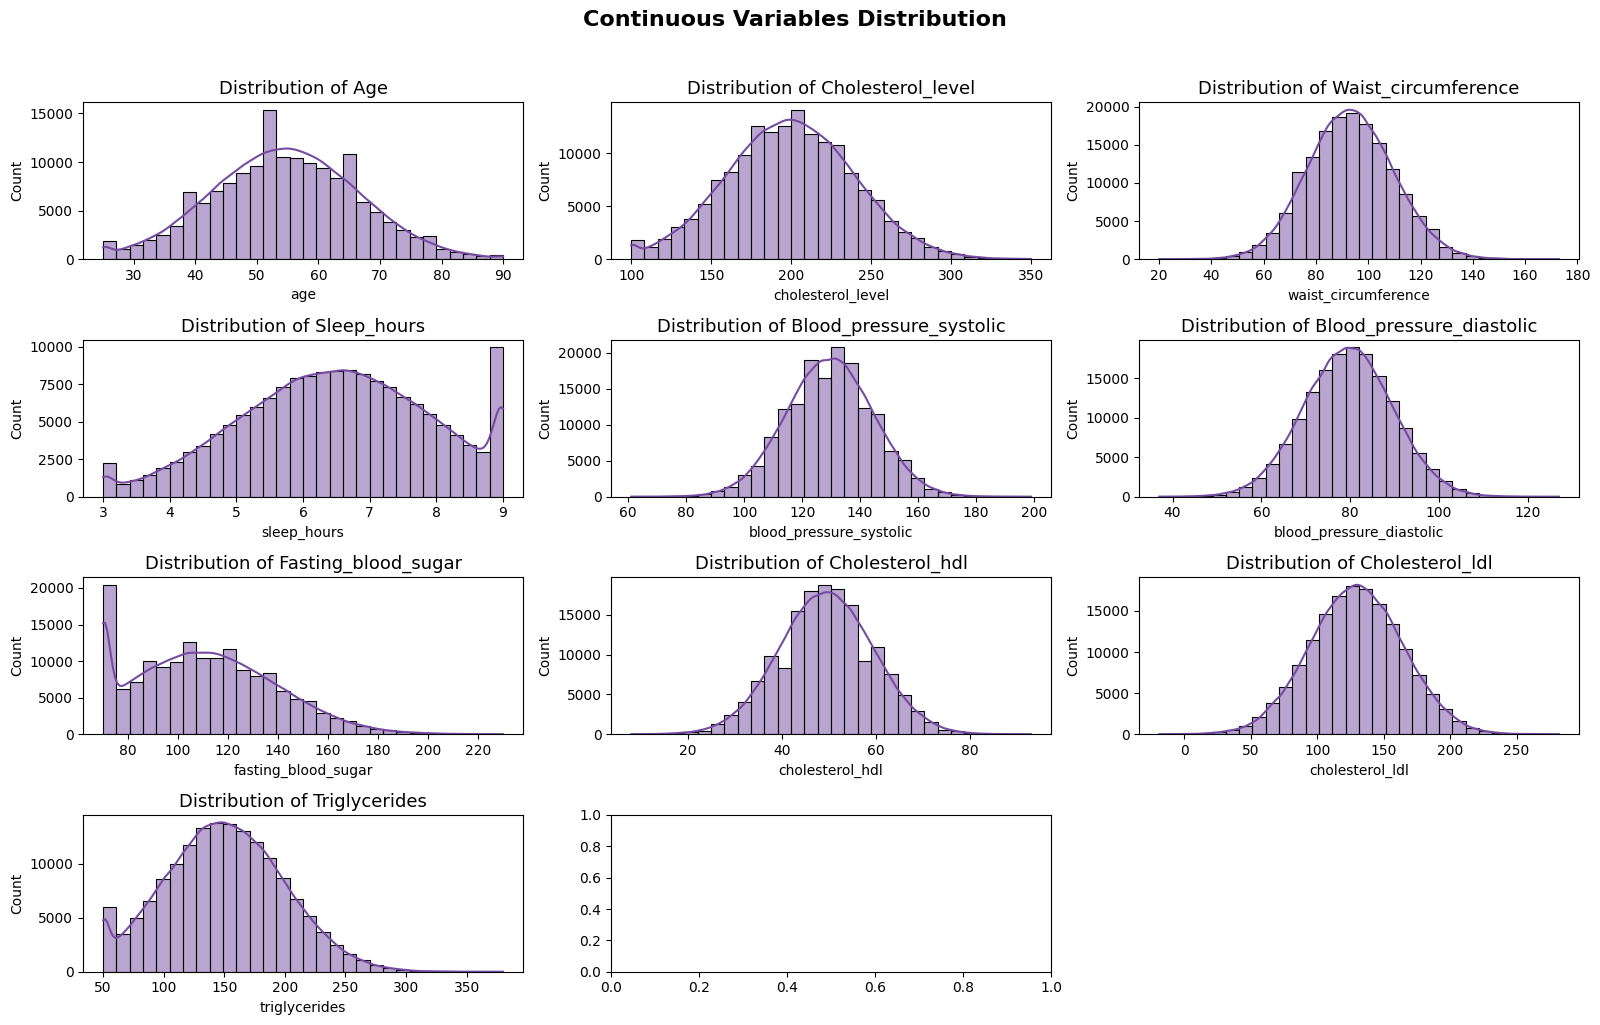

In [19]:
#distribution
# nums=df.select_dtypes(include=['int64','float64']).columns
nums=['age','cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(16, 10))
axes=ax.flatten()
for i, col in enumerate(nums):
    sns.histplot(df[col], bins=30, kde=True, color='#764ba2', ax=axes[i])
    plt.title(f'{col.capitalize()} Distribution', fontsize=14, fontweight='bold')
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
axes[-1].set_visible(False)
plt.suptitle('Continuous Variables Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
(df['waist_circumference']<45).sum()

np.int64(169)

In [21]:
(df['cholesterol_ldl']<10).sum()

np.int64(50)

In [31]:
# ((df['waist_circumference']<45) | (df['cholesterol_ldl']<10)|(df['sleep_hours']<1)|(df['blood_pressure_systolic']<60)|(df['blood_pressure_diastolic'<30])|(df['cholesterol_level']<80)|(df['fasting_blood_sugar']<30)|(df['cholesterol_hdl']<5)|(df['triglycerides']<20)).sum()

((df['waist_circumference']<45) | (df['cholesterol_ldl']<10)).sum()


np.int64(219)

In [32]:
df.drop(df[(df['waist_circumference']<45) | (df['cholesterol_ldl']<10)].index, inplace=True)

In [37]:
df.drop('alcohol_consumption',axis=1,inplace=True)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158136 entries, 0 to 158354
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158136 non-null  int64  
 1   gender                          158136 non-null  object 
 2   region                          158136 non-null  object 
 3   income_level                    158136 non-null  object 
 4   hypertension                    158136 non-null  int64  
 5   diabetes                        158136 non-null  int64  
 6   cholesterol_level               158136 non-null  int64  
 7   obesity                         158136 non-null  int64  
 8   waist_circumference             158136 non-null  int64  
 9   family_history                  158136 non-null  int64  
 10  smoking_status                  158136 non-null  object 
 11  physical_activity               158136 non-null  object 
 12  dietary_habits       

In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,158136.0,54.544569,11.911980,25.0,46.00000,55.000000,63.000000,90.0
hypertension,158136.0,0.299021,0.457831,0.0,0.00000,0.000000,1.000000,1.0
diabetes,158136.0,0.199828,0.399872,0.0,0.00000,0.000000,0.000000,1.0
cholesterol_level,158136.0,199.534110,39.740268,100.0,172.00000,199.000000,226.000000,350.0
obesity,158136.0,0.250190,0.433124,0.0,0.00000,0.000000,1.000000,1.0
waist_circumference,158136.0,93.326017,16.297834,45.0,82.00000,93.000000,104.000000,173.0
family_history,158136.0,0.300267,0.458375,0.0,0.00000,0.000000,1.000000,1.0
sleep_hours,158136.0,6.480361,1.425399,3.0,5.49316,6.507827,7.521005,9.0
blood_pressure_systolic,158136.0,129.515986,15.003515,61.0,119.00000,130.000000,140.000000,194.0
blood_pressure_diastolic,158136.0,79.491077,10.003726,37.0,73.00000,80.000000,86.000000,127.0


In [40]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,age,int64,"[54, 56, 55, 52, 53, 57, 58, 51, 50, 59]",66,0,0.0,0
1,gender,object,"[Male, Female]",2,0,0.0,0
2,region,object,"[Urban, Rural]",2,0,0.0,0
3,income_level,object,"[Middle, Low, High]",3,0,0.0,0
4,hypertension,int64,"[0, 1]",2,0,0.0,0
5,diabetes,int64,"[0, 1]",2,0,0.0,0
6,cholesterol_level,int64,"[203, 199, 198, 196, 197, 201, 207, 195, 200, ...",247,0,0.0,0
7,obesity,int64,"[0, 1]",2,0,0.0,0
8,waist_circumference,int64,"[91, 94, 93, 96, 95, 92, 98, 89, 90, 97]",116,0,0.0,0
9,family_history,int64,"[0, 1]",2,0,0.0,0


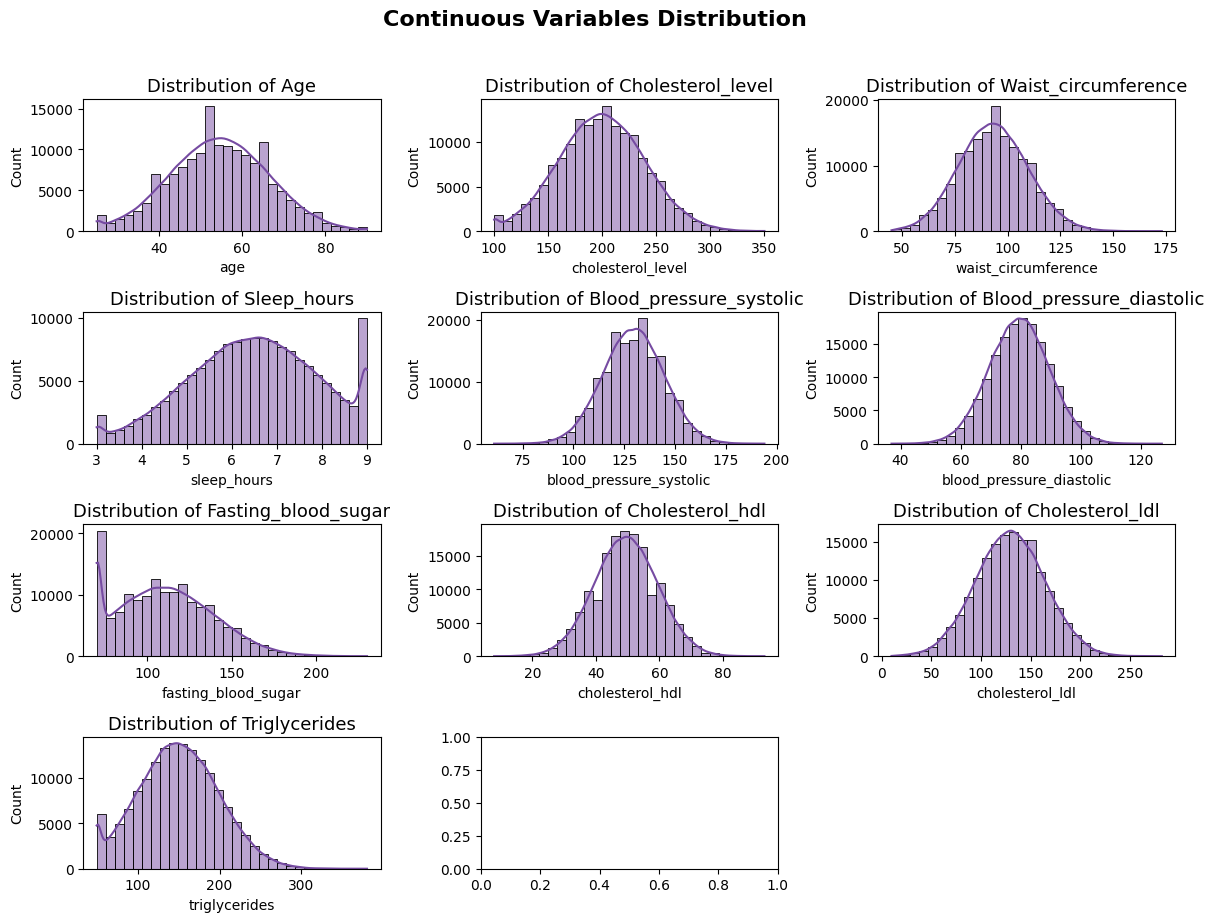

In [43]:
#distribution
# nums=df.select_dtypes(include=['int64','float64']).columns
nums=['age','cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 9))
axes=ax.flatten()
for i, col in enumerate(nums):
    sns.histplot(df[col], bins=30, kde=True, color='#764ba2', ax=axes[i])
    plt.title(f'{col.capitalize()} Distribution', fontsize=14, fontweight='bold')
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
axes[-1].set_visible(False)
plt.suptitle('Continuous Variables Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

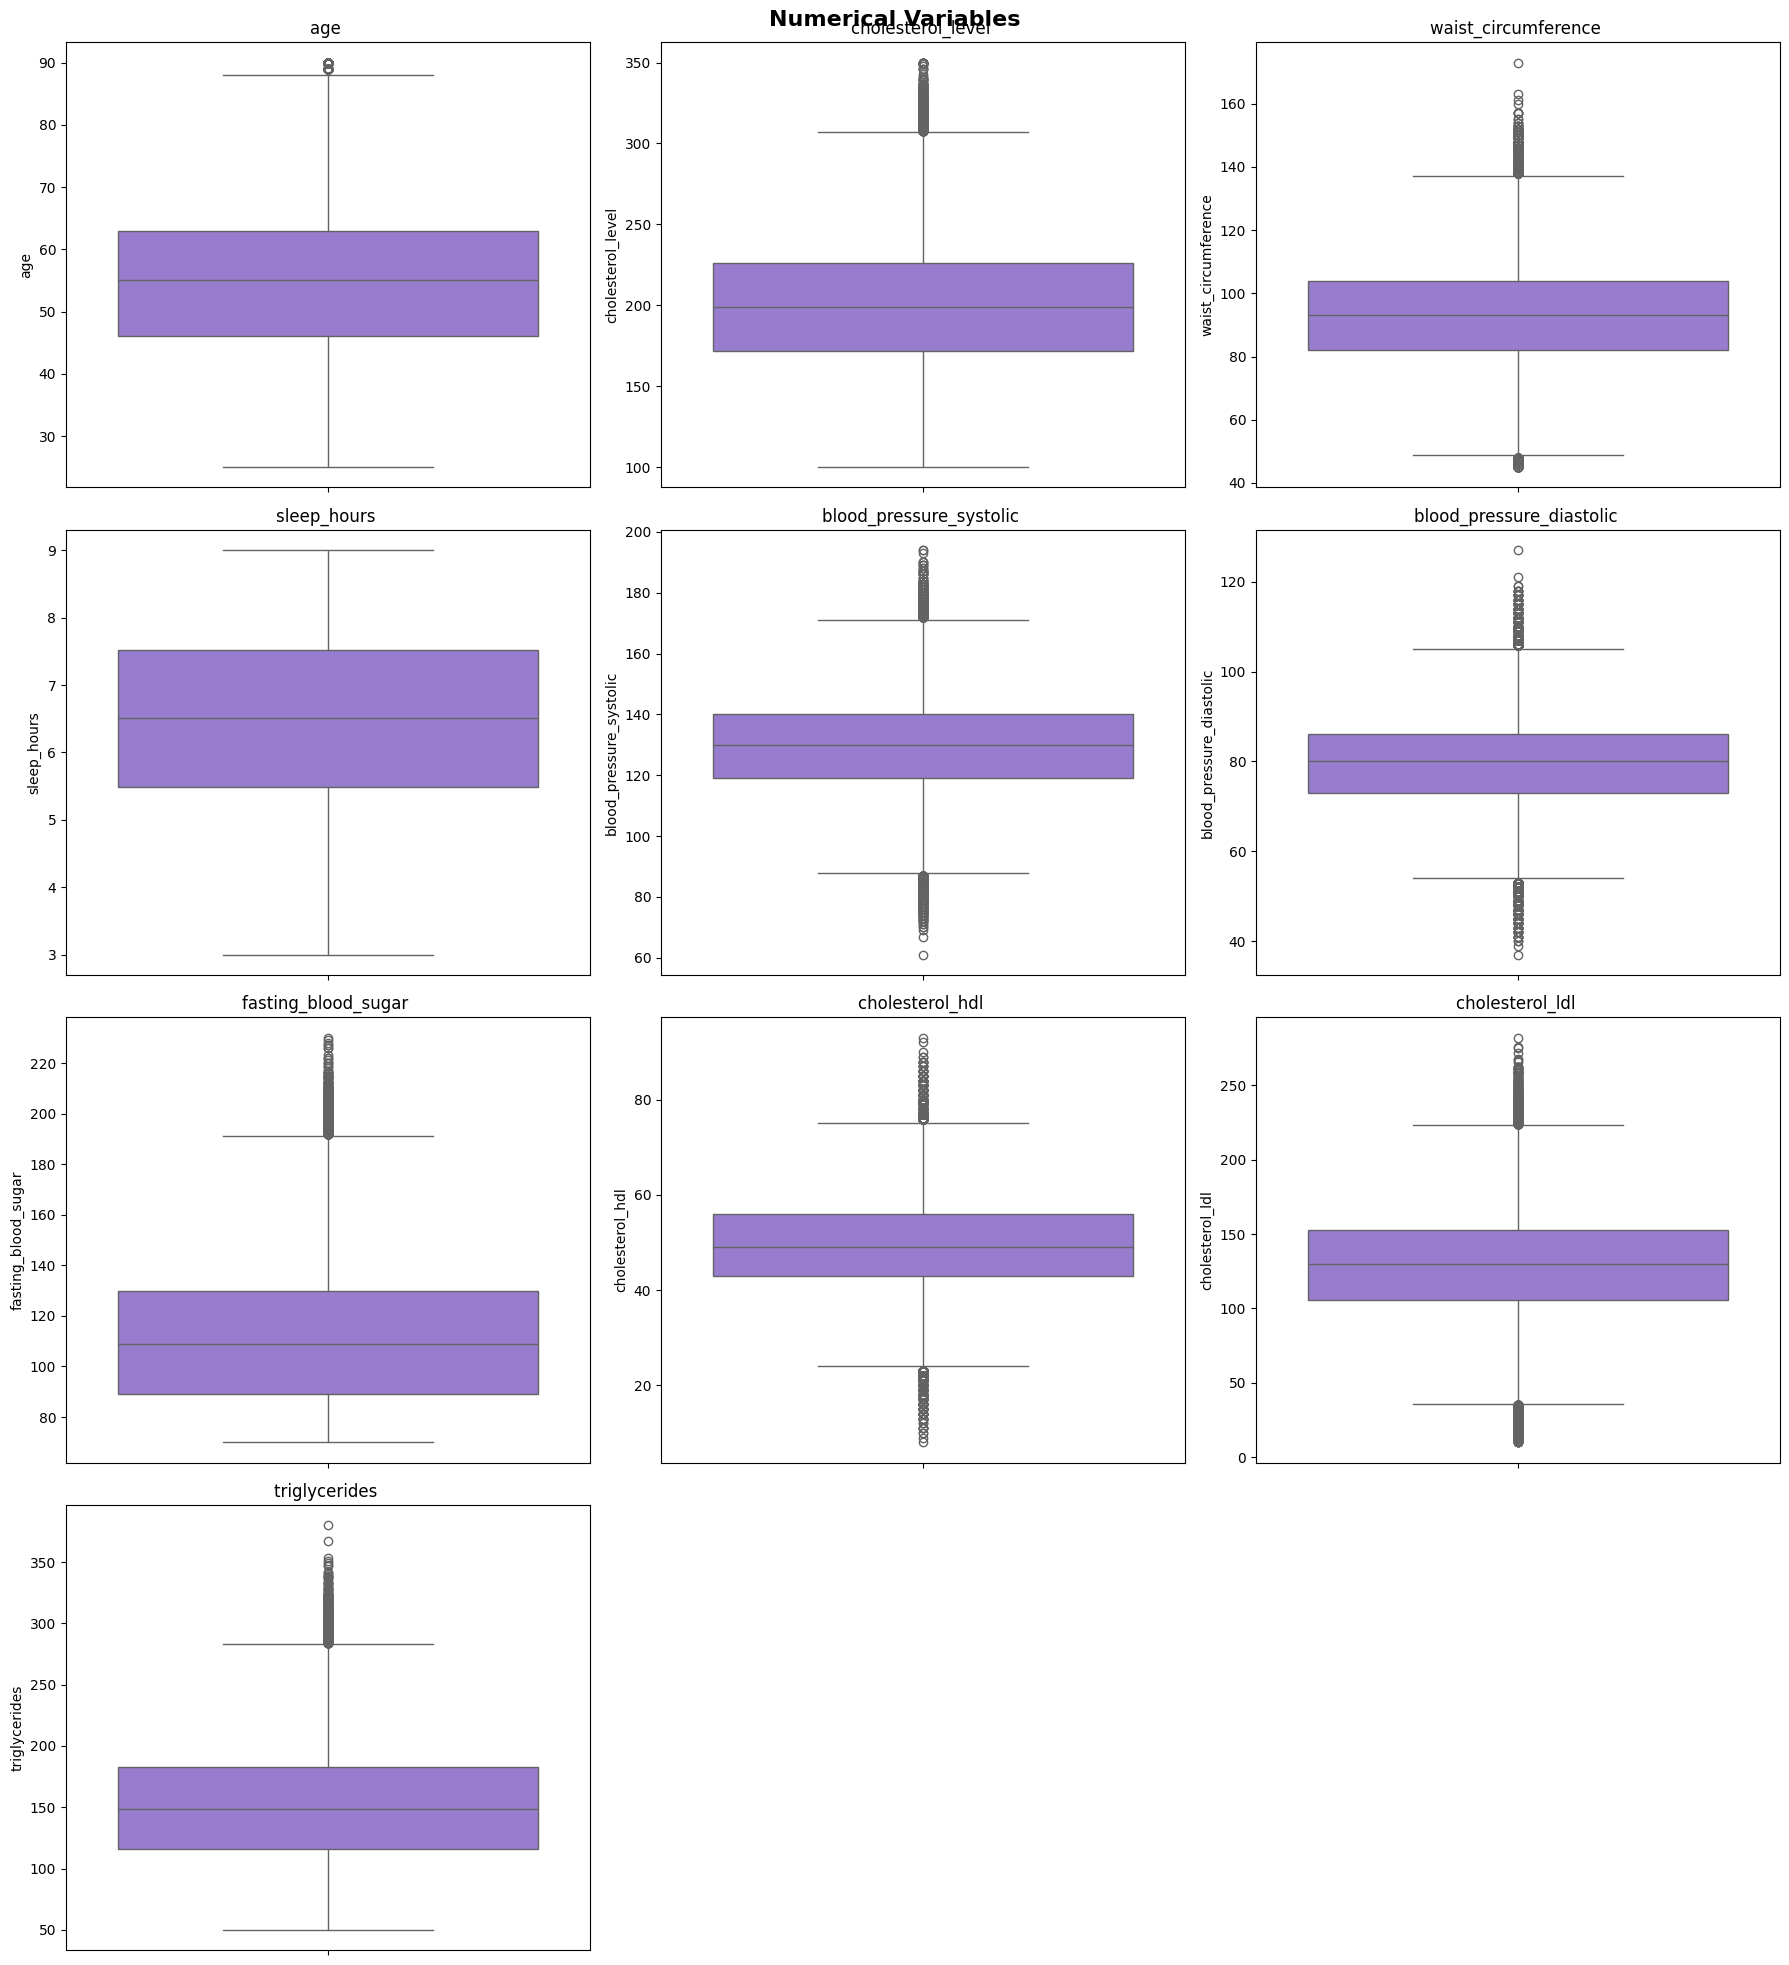

In [44]:
# nums=df.select_dtypes(include=['int64','float64']).columns
nums=['age','cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(nums):
    sns.boxplot(data=df, y=col, ax=axes[i],color='#9370DB')
    axes[i].set_title(f'{col} ', fontsize=12)
    axes[i].set_ylabel(col)

for j in range(len(nums), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##Feature Engneering


###-**Additional clinical categories** (Asian / Indonesian context)
**```Age```**
| Category | Age Range (years) | Interpretation |
|---|---|---|
| Young Adult | 25–39 | Lower age-related risk, but metabolic abnormalities can still occur |
| Middle-aged Adult | 40–59 | Increasing prevalence of hypertension, diabetes, and dyslipidemia |
| Older Adult | 60–74 | Higher risk of cardiovascular and metabolic diseases |
| Elderly | 75–90 | Highest age-related risk and higher prevalence of chronic conditions |
---
**```Waist circumference```**
| Category | Value / Range | Interpretation |
|---|---|---|
| Lower risk | Men < 90 cm, Women < 80 cm | Lower metabolic risk |
| Increased risk | Men ≥ 90 cm, Women ≥ 80 cm | Increased risk of insulin resistance and metabolic syndrome |
| Severe obesity range | ≥ 120 cm | Very high abdominal obesity risk |
---
**```Blood pressure (Systolic)```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Optimal | < 120 mmHg | Optimal blood pressure |
| Normal | 120–129 mmHg | Normal range |
| High Normal | 130–139 mmHg | Above normal; lifestyle modification recommended |
| Grade 1 Hypertension | 140–159 mmHg | Mild hypertension |
| Grade 2 Hypertension | 160–179 mmHg | Moderate hypertension |
| Grade 3 Hypertension | ≥ 180 mmHg | Severe hypertension; critical clinical condition |
| Severe Hypotension | < 70 mmHg | Critical low pressure but survivable |
---
**```Blood pressure (Diastolic)```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Optimal | < 80 mmHg | Optimal diastolic pressure |
| Normal | 80–84 mmHg | Normal range |
| High Normal | 85–89 mmHg | Above normal; lifestyle modification recommended |
| Grade 1 Hypertension | 90–99 mmHg | Mild diastolic hypertension |
| Grade 2 Hypertension | 100–109 mmHg | Moderate diastolic hypertension |
| Grade 3 Hypertension | ≥ 110 mmHg | Severe diastolic hypertension |
| Severe Hypotension | < 40 mmHg | Critical low pressure but survivable |
---
**```Fasting blood sugar```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Normal | < 100 mg/dL | Normal glucose regulation |
| Prediabetes | 100–125 mg/dL | Increased diabetes risk |
| Diabetes range | ≥ 126 mg/dL | Diabetes-level fasting glucose |
| Severe hyperglycemia | ≥ 300 mg/dL | High-risk clinical condition |
| Extreme but survivable | 600–700 mg/dL | Reported in living patients |

---
**```Total cholesterol (cholesterol_level)```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Desirable | < 200 mg/dL | Lower cardiovascular risk |
| Borderline high | 200–239 mg/dL | Moderate risk |
| High | ≥ 240 mg/dL | Increased cardiovascular risk |
| Extreme | ≥ 400 mg/dL | Severe dyslipidemia |

---
**```LDL cholesterol```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Optimal | < 100 mg/dL | Preferred level |
| High | 160–189 mg/dL | Increased risk |
| Very high | ≥ 190 mg/dL | Severe LDL elevation |
---
**```HDL cholesterol```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Low risk | ≥ 40 mg/dL (men), ≥ 50 mg/dL (women) | Protective level |
| Low | < 40 mg/dL | Increased metabolic risk |
| Very low | < 20 mg/dL | Severe HDL deficiency |
---
**```Triglycerides```**

| Category | Value / Range | Interpretation |
|---|---|---|
| Normal | < 150 mg/dL | Normal lipid level |
| High | 200–499 mg/dL | Increased cardiovascular risk |
| Very high | ≥ 500 mg/dL | High pancreatitis risk |
| Extreme | ≥ 1000 mg/dL | Severe hypertriglyceridemia |
---
**```Sleep Hours```**

| Category | Sleep Duration (hours/day) | Interpretation |
|---|---|---|
| Very Short Sleep | < 5 hours | Associated with higher metabolic and cardiovascular risk |
| Short Sleep | 5–6 hours | Slightly increased health risk in many studies |
| Recommended Range | 7–9 hours | Generally associated with better health outcomes in adults |
| Long Sleep | 10–12 hours | May be associated with increased health risks |
| Extreme Long Sleep | > 12 hours | Uncommon; may indicate underlying health conditions |
---
# References with Links

| Reference | Link |
|---|---|
| WHO Expert Consultation - Asian BMI and metabolic risk | https://doi.org/10.1016/S0140-6736(03)15268-3 |
| Alberti et al. Harmonizing Metabolic Syndrome | https://doi.org/10.1161/CIRCULATIONAHA.109.192644 |
| Indonesian Society of Hypertension (InaSH) Consensus 2019 | https://inash.or.id |
| American Diabetes Association Standards of Care | https://diabetesjournals.org/care |
| NCEP ATP III Report | https://www.nhlbi.nih.gov/files/docs/guidelines/atp3xsum.pdf |
| Berglund Hypertriglyceridemia Statement | https://doi.org/10.1161/CIR.0b013e3182160726 |
| Itani Sleep Meta-analysis | https://doi.org/10.1016/j.sleep.2017.05.015 |
| Riskesdas Indonesia | https://www.badankebijakan.kemkes.go.id |